## 0. Load data set

In [ ]:
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 61.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 29.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 136.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
from transformers import BertModel, BertTokenizer
import pickle
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU available.


In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Mount data
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')

# Mount validation data
val_df = pd.read_csv('/content/gdrive/My Drive/MSc Project/val_df.csv')

# Mount original train data and augmented data
train_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_df.csv")
train_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_eda_60.0.csv")
train_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/backtrans_60.csv")
train_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/backtrans_ko_60.csv")

# Mount 1% subsampled data and augmented data
subset01_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset.csv")
subset01_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset_eda_60.0.csv")
subset01_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset_backtrans_60.csv")
subset01_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset_backtrans_ko60.csv")

# Mount 5% subsampled data and augmented data
subset05_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset5.csv")
subset05_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset5_eda_60.0.csv")
subset05_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset5_backtrans_60.csv")
subset05_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset05_backtrans_ko60.csv")

# Mount 10% subsampled data and augmented data
subset10_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset10.csv")
subset10_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset10_eda_60.0.csv")
subset10_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset10_backtrans_60.csv")
subset10_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset10_backtrans_ko60.csv")

# Mount 20% subsampled data and augmented data
subset20_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset20.csv")
subset20_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset20_eda_60.0.csv")
subset20_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset20_backtrans_60.csv")
subset20_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset20_backtrans_ko60.csv")

# Mount 30% subsampled data and augmented data
subset30_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset30.csv")
subset30_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset30_eda_60.0.csv")
subset30_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset30_backtrans_60.csv")
subset30_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset30_backtrans_ko60.csv")

## Sentence Embedding : Bert

In [ ]:
# Load BERT model and tokenizer
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertModel.from_pretrained('bert-base-uncased').to(device)

In [ ]:
# Define the collate function for tokenization
def collate_fn(batch):
    return tokenizer_bert(batch, padding='max_length', truncation=True, max_length=512, return_tensors='pt')

# Define the mean pooling function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state  # Last hidden state contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

def get_bert_embeddings(df, text_column="text"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Create a TextDataset
    class TextDataset(Dataset):
        def __init__(self, texts):
            self.texts = texts

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            return self.texts[idx]

    dataset = TextDataset(list(df[text_column]))

    # Create a DataLoader
    dataloader = DataLoader(dataset, batch_size=16, collate_fn=collate_fn)

    # Initialize a list to store the embeddings
    embeddings_bert = []

    # Iterate over the batches
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        with torch.no_grad():
            model_output = model_bert(input_ids, attention_mask=attention_mask)

        sentence_embeddings = mean_pooling(model_output, attention_mask)
        embeddings_bert.extend(sentence_embeddings.cpu().numpy())

    return embeddings_bert

In [ ]:
# Define a function to store embeddings and sentences using pickle
def store_embeddings_and_sentences(embeddings, sentences, output_path):
    with open(output_path, "wb") as fOut:
        pickle.dump({'sentences': sentences, 'embeddings': embeddings}, fOut, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# Get embeddings and store for different datasets
datasets_to_process = [
    (val_df, "bert_embeddings_val.pkl"),
    (train_original, "bert_embeddings_train_original.pkl"),
    (train_eda_60perc, "bert_embeddings_train_eda_60perc.pkl"),
    (train_bt_60perc, "bert_embeddings_train_bt_60perc.pkl"),
    (train_bt_ko_60perc, "bert_embeddings_train_bt_ko_60perc.pkl"),
    (subset01_original, "bert_embeddings_subset01_original.pkl"),
    (subset01_eda_60perc, "bert_embeddings_subset01_eda_60perc.pkl"),
    (subset01_bt_60perc, "bert_embeddings_subset01_bt_60perc.pkl"),
    (subset01_bt_ko_60perc, "bert_embeddings_subset01_bt_ko_60perc.pkl"),
    (subset05_original, "bert_embeddings_subset05_original.pkl"),
    (subset05_eda_60perc, "bert_embeddings_subset05_eda_60perc.pkl"),
    (subset05_bt_60perc, "bert_embeddings_subset05_bt_60perc.pkl"),
    (subset05_bt_ko_60perc, "bert_embeddings_subset05_bt_ko_60perc.pkl"),
    (subset10_original, "bert_embeddings_subset10_original.pkl"),
    (subset10_eda_60perc, "bert_embeddings_subset10_eda_60perc.pkl"),
    (subset10_bt_60perc, "bert_embeddings_subset10_bt_60perc.pkl"),
    (subset10_bt_ko_60perc, "bert_embeddings_subset10_bt_ko_60perc.pkl"),
    (subset20_original, "bert_embeddings_subset20_original.pkl"),
    (subset20_eda_60perc, "bert_embeddings_subset20_eda_60perc.pkl"),
    (subset20_bt_60perc, "bert_embeddings_subset20_bt_60perc.pkl"),
    (subset20_bt_ko_60perc, "bert_embeddings_subset20_bt_ko_60perc.pkl"),
    (subset30_original, "bert_embeddings_subset30_original.pkl"),
    (subset30_eda_60perc, "bert_embeddings_subset30_eda_60perc.pkl"),
    (subset30_bt_60perc, "bert_embeddings_subset30_bt_60perc.pkl"),
    (subset30_bt_ko_60perc, "bert_embeddings_subset30_bt_ko_60perc.pkl"),
]

for dataset, output_filename in datasets_to_process:
    b_embeddings = get_bert_embeddings(dataset)
    store_embeddings_and_sentences(b_embeddings, dataset['text'].tolist(), f'/content/gdrive/My Drive/MSc Project/{output_filename}')

## Sentence Embedding : Roberta



In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base').to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define a function to tokenize a batch of texts
def collate_fn(batch):
    return tokenizer(batch, padding='max_length', truncation=True, max_length=512, return_tensors='pt')

# Define the mean pooling function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  # First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

def get_roberta_embeddings(df, text_column="text"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Create a TextDataset
    class TextDataset(Dataset):
        def __init__(self, texts):
            self.texts = texts

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            return self.texts[idx]

    dataset = TextDataset(list(df[text_column]))

    # Create a DataLoader
    dataloader = DataLoader(dataset, batch_size=16, collate_fn=collate_fn)

    # Initialize a list to store the embeddings
    embeddings_roberta = []

    # Iterate over the batches
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        with torch.no_grad():
            model_output = model(input_ids, attention_mask=attention_mask)

        sentence_embeddings = mean_pooling(model_output, attention_mask)
        embeddings_roberta.extend(sentence_embeddings.cpu().numpy())

    return embeddings_roberta

In [ ]:
# Define a function to store embeddings and sentences using pickle
def store_embeddings_and_sentences(embeddings, sentences, output_path):
    with open(output_path, "wb") as fOut:
        pickle.dump({'sentences': sentences, 'embeddings': embeddings}, fOut, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# Get embeddings and store for different datasets
datasets_to_process = [
    (val_df, "roberta_embeddings_val.pkl"),
    (train_original, "roberta_embeddings_train_original.pkl"),
    (train_eda_60perc, "roberta_embeddings_train_eda_60perc.pkl"),
    (train_bt_60perc, "roberta_embeddings_train_bt_60perc.pkl"),
    (train_bt_ko_60perc, "roberta_embeddings_train_bt_ko_60perc.pkl"),
    (subset01_original, "roberta_embeddings_subset01_original.pkl"),
    (subset01_eda_60perc, "roberta_embeddings_subset01_eda_60perc.pkl"),
    (subset01_bt_60perc, "roberta_embeddings_subset01_bt_60perc.pkl"),
    (subset01_bt_ko_60perc, "roberta_embeddings_subset01_bt_ko_60perc.pkl"),
    (subset05_original, "roberta_embeddings_subset05_original.pkl"),
    (subset05_eda_60perc, "roberta_embeddings_subset05_eda_60perc.pkl"),
    (subset05_bt_60perc, "roberta_embeddings_subset05_bt_60perc.pkl"),
    (subset05_bt_ko_60perc, "roberta_embeddings_subset05_bt_ko_60perc.pkl"),
    (subset10_original, "roberta_embeddings_subset10_original.pkl"),
    (subset10_eda_60perc, "roberta_embeddings_subset10_eda_60perc.pkl"),
    (subset10_bt_60perc, "roberta_embeddings_subset10_bt_60perc.pkl"),
    (subset10_bt_ko_60perc, "roberta_embeddings_subset10_bt_ko_60perc.pkl"),
    (subset20_original, "roberta_embeddings_subset20_original.pkl"),
    (subset20_eda_60perc, "roberta_embeddings_subset20_eda_60perc.pkl"),
    (subset20_bt_60perc, "roberta_embeddings_subset20_bt_60perc.pkl"),
    (subset20_bt_ko_60perc, "roberta_embeddings_subset20_bt_ko_60perc.pkl"),
    (subset30_original, "roberta_embeddings_subset30_original.pkl"),
    (subset30_eda_60perc, "roberta_embeddings_subset30_eda_60perc.pkl"),
    (subset30_bt_60perc, "roberta_embeddings_subset30_bt_60perc.pkl"),
    (subset30_bt_ko_60perc, "roberta_embeddings_subset30_bt_ko_60perc.pkl"),
]

for dataset, output_filename in datasets_to_process:
    r_embeddings = get_roberta_embeddings(dataset)
    store_embeddings_and_sentences(r_embeddings, dataset['text'].tolist(), f'/content/gdrive/My Drive/MSc Project/{output_filename}')


## Check Embeddings

Visualize similarity in sentiment

In [ ]:
def visualize_embeddings(embeddings, labels):
    color_dict = {'.1': 'limegreen', '.-1': 'tomato', '.0': 'royalblue'}
    marker_dict = {'.1': 'o', '.-1': 'x', '.0': 's'}  # Circle, Cross, Square

    def get_attr_for_label(label_list_str):
        label_list = ast.literal_eval(label_list_str)  # Convert string representation of list to actual list
        sentiment = '.' + label_list[0].split('.')[-1]
        return color_dict[sentiment], marker_dict[sentiment]

    attrs = labels.apply(get_attr_for_label)
    color_list = [attr[0] for attr in attrs]
    marker_list = [attr[1] for attr in attrs]

    embeddings_np = np.array(embeddings)
    tsne = TSNE(n_components=2)
    reduced_embeddings = tsne.fit_transform(embeddings_np)

    plt.figure(figsize=(8, 8))
    for idx, coords in enumerate(reduced_embeddings):
        plt.scatter(coords[0], coords[1], c=color_list[idx], marker=marker_list[idx], alpha=0.7)

    # Adjusted legend_elements
    legend_elements = [
        mlines.Line2D([0], [0], color='limegreen', marker='o', markersize=10, label='Positive', linestyle='None'),
        mlines.Line2D([0], [0], color='tomato', marker='x', markersize=10, label='Negative', linestyle='None'),
        mlines.Line2D([0], [0], color='royalblue', marker='s', markersize=10, label='Neutral', linestyle='None')
    ]

    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

    check_1 = 0
    check_2 = 2

    similarity = cosine_similarity(
        embeddings[check_1].reshape(1, -1),
        embeddings[check_2].reshape(1, -1)
    )
    print(f"Cosine similarity between two embeddings: {similarity[0][0]}")
    print(labels[check_1])
    print(labels[check_2])


Bert

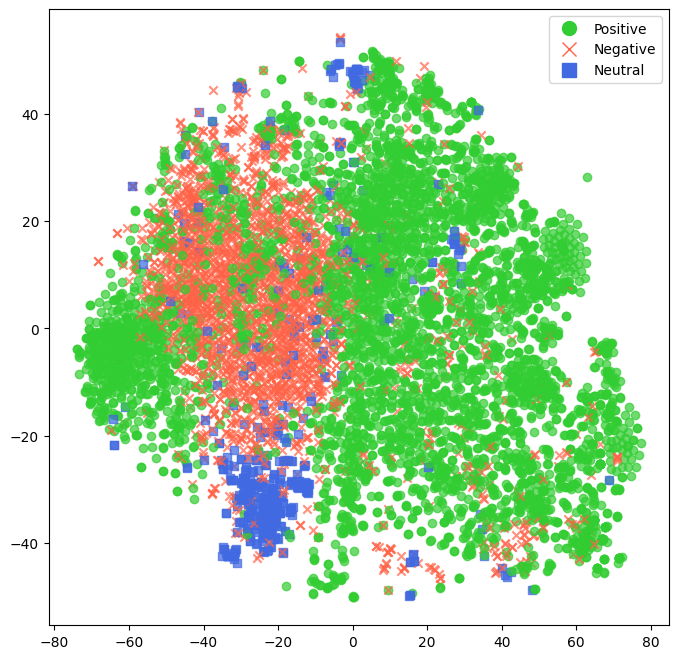

Cosine similarity between two embeddings: 0.6662567853927612
['company-brand.reviews.1']
['account-management.account-access.-1', 'online-experience.app-website.-1']


In [ ]:
datasets_to_process = [
    ("bert_embeddings_train_original.pkl", train_original['labels']),
]

for filename, labels in datasets_to_process:
    with open(f'/content/gdrive/My Drive/MSc Project/{filename}', "rb") as f:
        data = pickle.load(f)
        embeddings = data['embeddings']

        visualize_embeddings(embeddings, labels)

Roberta

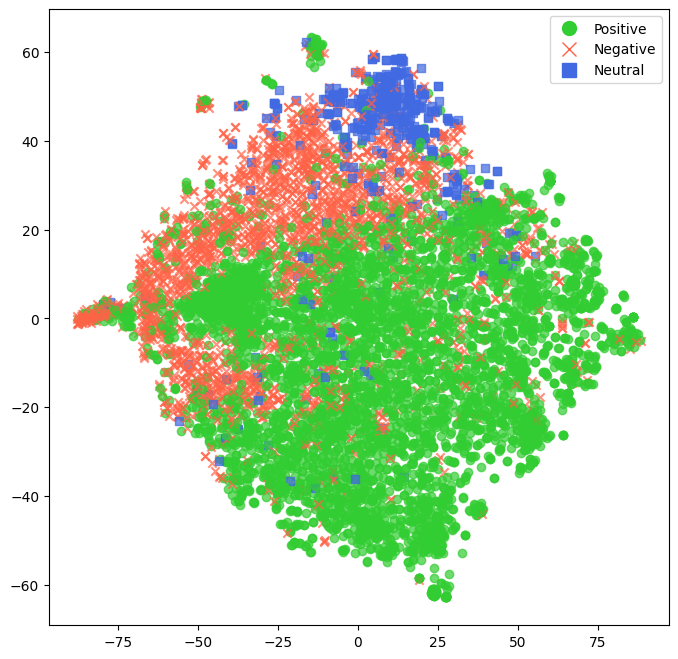

Cosine similarity between two embeddings: 0.9696369171142578
['company-brand.reviews.1']
['account-management.account-access.-1', 'online-experience.app-website.-1']


In [ ]:
datasets_to_process = [
    ("roberta_embeddings_train_original.pkl", train_original['labels']),
]

for filename, labels in datasets_to_process:
    with open(f'/content/gdrive/My Drive/MSc Project/{filename}', "rb") as f:
        data = pickle.load(f)
        embeddings = data['embeddings']

        visualize_embeddings(embeddings, labels)

Visualize similarity in categories

In [ ]:
def visualize_embeddings_by_category(embeddings, labels):
    # Define a list of colors for the categories
    colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black', 'purple', 'pink', 'brown', 'orange', 'teal']

    # Get the unique categories
    categories = labels.apply(lambda x: x.split('.')[0]).unique()

    # Create a mapping from categories to colors
    color_dict = dict(zip(categories, colors))

    # Create a color list based on categories
    color_list = [color_dict[x.split('.')[0]] for x in labels]

    # Perform t-SNE on the numpy array of embeddings
    tsne = TSNE(n_components=2)
    reduced_embeddings = tsne.fit_transform(embeddings)

    # Plot the reduced embeddings
    plt.figure(figsize=(8, 8))
    for i, category in enumerate(categories):
        plt.scatter(reduced_embeddings[labels.apply(lambda x: x.split('.')[0]) == category, 0],
                    reduced_embeddings[labels.apply(lambda x: x.split('.')[0]) == category, 1],
                    color=colors[i],
                    alpha=0.5,
                    label=category)
    plt.legend()
    plt.show()

Bert

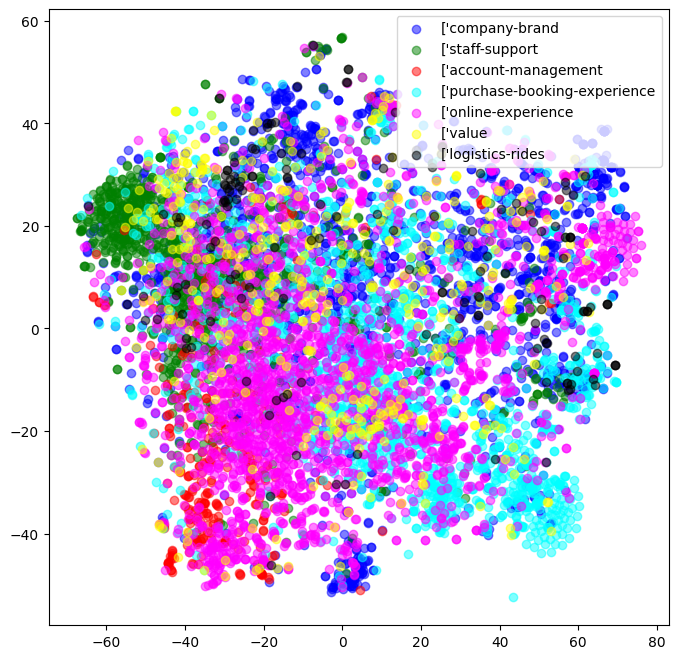

In [ ]:
datasets_to_process = [
    ("bert_embeddings_train_original.pkl", train_original['labels']),
]

for filename, labels in datasets_to_process:
    with open(f'/content/gdrive/My Drive/MSc Project/{filename}', "rb") as f:
        data = pickle.load(f)
        embeddings = np.array(data['embeddings'])  # Convert to numpy array

        visualize_embeddings_by_category(embeddings, labels)

Roberta

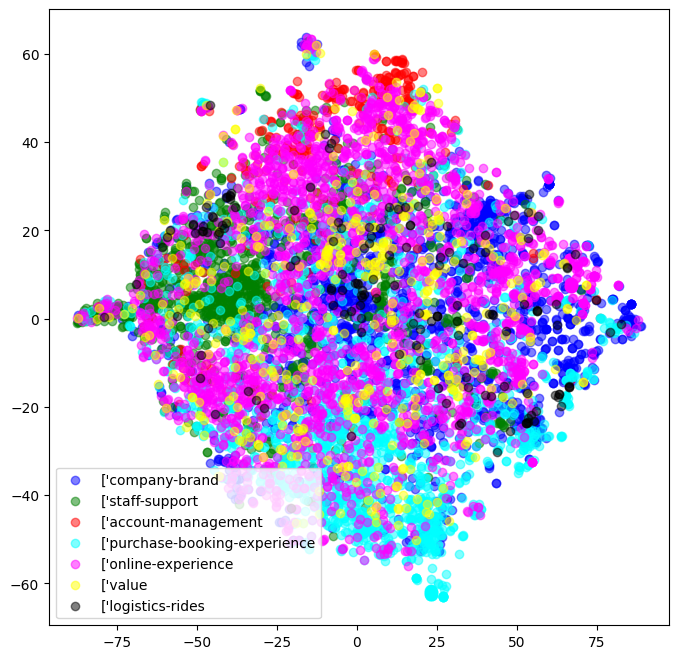

In [ ]:
    ("roberta_embeddings_train_original.pkl", train_original['labels']),
]

for filename, labels in datasets_to_process:
    with open(f'/content/gdrive/My Drive/MSc Project/{filename}', "rb") as f:
        data = pickle.load(f)
        embeddings = np.array(data['embeddings'])  # Convert to numpy array

        visualize_embeddings_by_category(embeddings, labels)